# 1)Import necessary libraries

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
import statsmodels.api as sm


from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay


## 2) Import the Dataset

In [3]:
# Load the dataset
file_path = "C:\\Users\\91705\\data science\\DS19thJuly24-2-30-to-4-30-main_(1)[1]\\AAPL.csv"
data = pd.read_csv(file_path)

In [4]:
# Convert the Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# **EDA-Exploratory Data Analysis**

In [5]:
print("\nFirst 5 Rows of Data:")
print(data.head())


First 5 Rows of Data:
        Date       Open       High        Low      Close  Adj Close    Volume
0 2012-01-03  58.485714  58.928570  58.428570  58.747143  50.765709  75555200
1 2012-01-04  58.571430  59.240002  58.468571  59.062859  51.038536  65005500
2 2012-01-05  59.278572  59.792858  58.952858  59.718571  51.605175  67817400
3 2012-01-06  59.967144  60.392857  59.888573  60.342857  52.144630  79573200
4 2012-01-09  60.785713  61.107143  60.192856  60.247143  52.061932  98506100


In [6]:
data.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
2006,2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000
2007,2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700
2008,2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300
2009,2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500
2010,2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600


In [7]:
#No.of rows & columns
data.shape

(2011, 7)

In [8]:

# Basic Dataset Information
print("Dataset Information:")
print(data.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2011 non-null   datetime64[ns]
 1   Open       2011 non-null   float64       
 2   High       2011 non-null   float64       
 3   Low        2011 non-null   float64       
 4   Close      2011 non-null   float64       
 5   Adj Close  2011 non-null   float64       
 6   Volume     2011 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 110.1 KB
None


In [9]:
# checking for the duplicate values
data.duplicated().sum()

0

In [10]:
print("\nSummary Statistics:")
print(data.describe())



Summary Statistics:
                                Date         Open         High          Low  \
count                           2011  2011.000000  2011.000000  2011.000000   
mean   2016-01-01 03:10:28.344107520   126.707469   127.827594   125.580258   
min              2012-01-03 00:00:00    55.424286    57.085712    55.014286   
25%              2014-01-02 12:00:00    85.882858    86.717858    85.056427   
50%              2015-12-31 00:00:00   113.050003   114.190002   111.870003   
75%              2017-12-28 12:00:00   165.190002   167.409996   163.424995   
max              2019-12-30 00:00:00   291.119995   293.970001   288.119995   
std                              NaN    50.483753    50.926301    50.124940   

             Close    Adj Close        Volume  
count  2011.000000  2011.000000  2.011000e+03  
mean    126.741235   119.505548  5.949670e+07  
min      55.790001    48.921928  1.136200e+07  
25%      86.202145    75.056679  2.758565e+07  
50%     113.050003   105.22

In [11]:
# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [12]:
# Add additional features for analysis
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day

## 3) Visualization

In [13]:

# Plotting
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

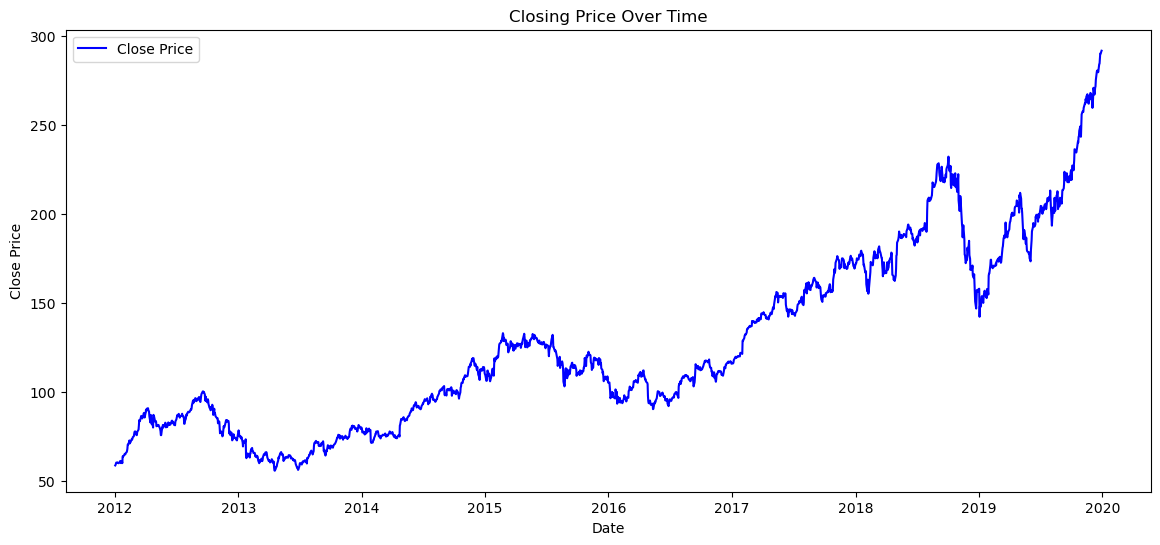

In [14]:
# Line plot of Closing Price over time
plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Close'], label='Close Price', color='blue')
plt.title('Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()

<Axes: xlabel='Adj Close', ylabel='Density'>

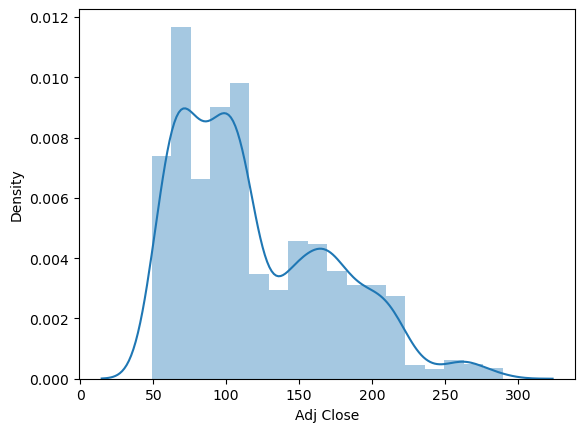

In [15]:
sns.distplot(data['Adj Close'],kde=True)

Text(0.5, 0, 'Close Price')

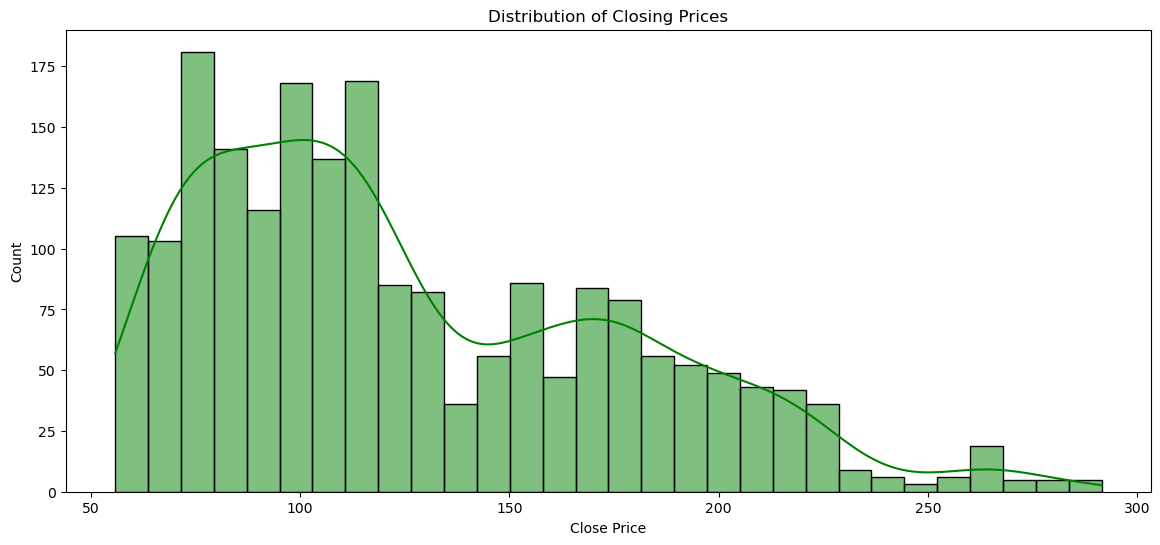

In [16]:
# Histogram of Closing Prices
plt.figure(figsize=(14, 6))
sns.histplot(data['Close'], kde=True, color='green', bins=30)
plt.title('Distribution of Closing Prices')
plt.xlabel('Close Price')

Text(0.5, 1.0, 'Boxplot of High and Low Prices')

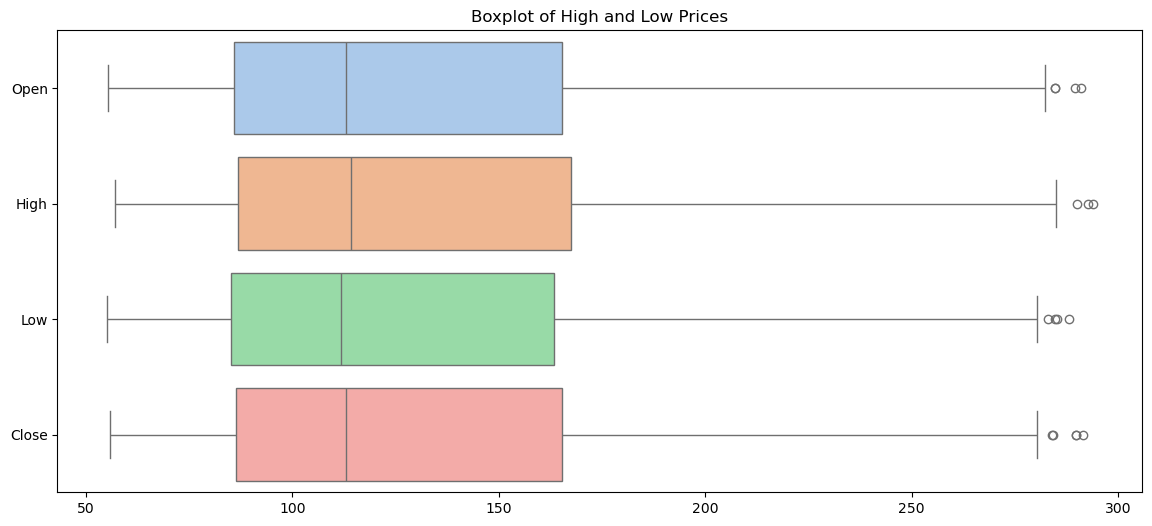

In [17]:
# Boxplot of High and Low Prices
plt.figure(figsize=(14, 6))
sns.boxplot(data=data[['Open', 'High', 'Low', 'Close']], orient='h', palette='pastel')
plt.title('Boxplot of High and Low Prices')


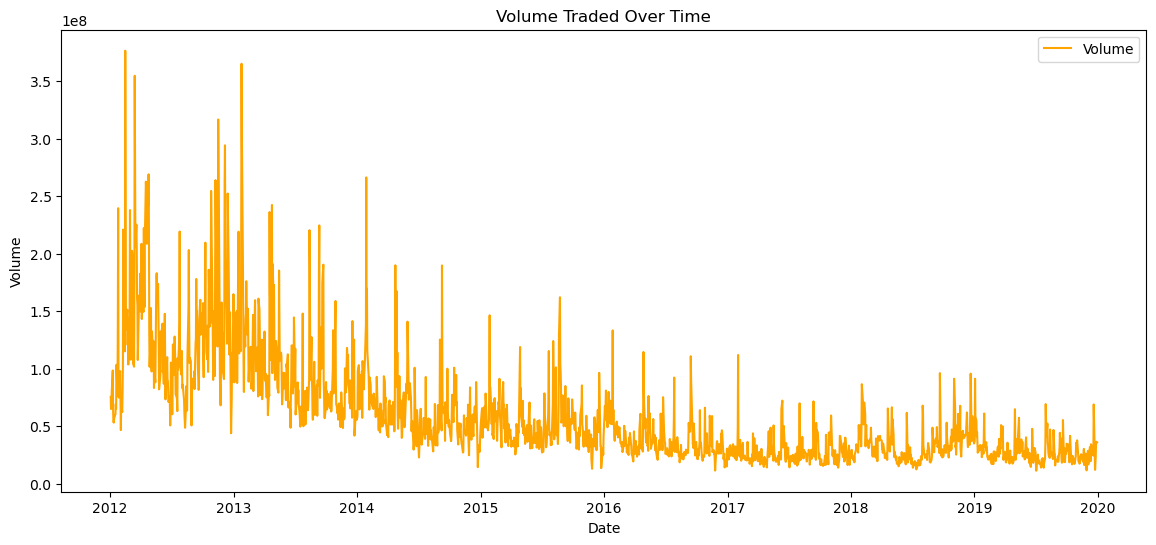

In [18]:
# Volume traded over time
plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Volume'], label='Volume', color='orange')
plt.title('Volume Traded Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()

In [19]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

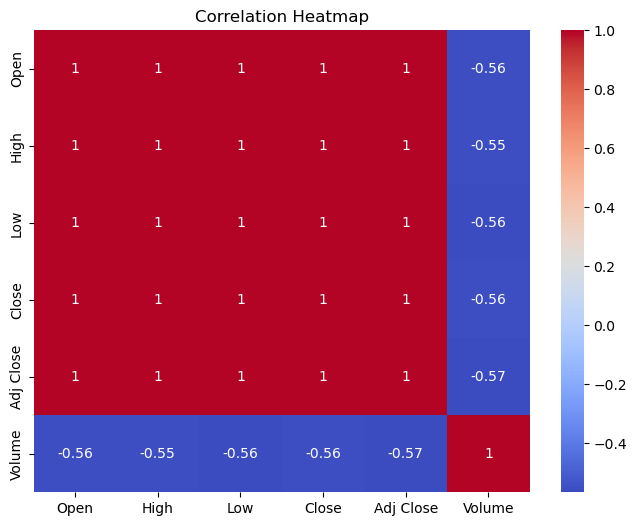

In [20]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [21]:

# Closing Price grouped by Year
avg_close_by_year = data.groupby('Year')['Close'].mean()
print("\nAverage Closing Price by Year:")
print(avg_close_by_year)


Average Closing Price by Year:
Year
2012     82.292817
2013     67.519269
2014     92.264654
2015    120.040000
2016    104.604008
2017    150.551075
2018    189.053427
2019    207.915737
Name: Close, dtype: float64


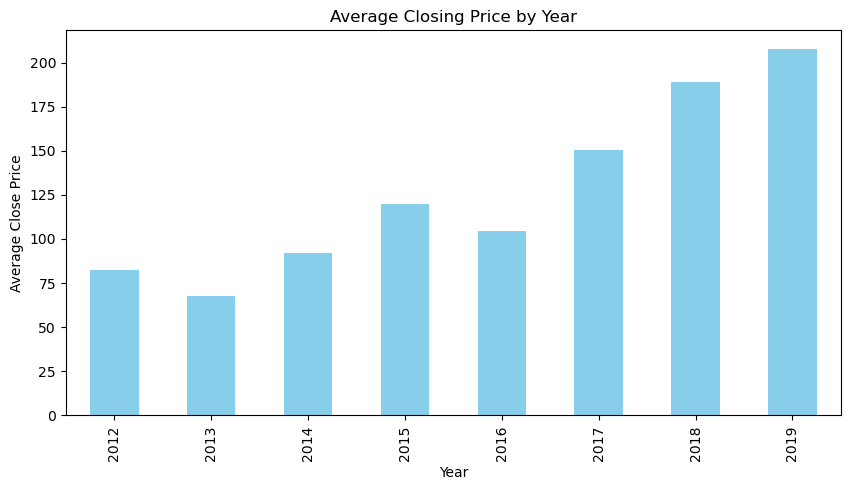

In [22]:
# Barplot for yearly averages
plt.figure(figsize=(10, 5))
avg_close_by_year.plot(kind='bar', color='skyblue')
plt.title('Average Closing Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Close Price')
plt.show()

In [23]:
from statsmodels.tsa.stattools import adfuller

In [24]:
def adf_test(series, title=''):

    # .dropna() handles differenced data
    result = adfuller(series.dropna(),autolag='AIC')

    print('Agumented Dicky-Fuller test')
    labels = ['ADF test statistic :','p-value :','No. of Lags :']
    out = pd.Series(result[0:3],index=labels)

    for key,val in result[4].items():
        out['critical value ({}) :'.format(key)]=val

    # .to_string() removes the line "dtype: float64"
    print(out.to_string())

    if result[1] <= 0.05:
        print("\nReject the null hypothesis")
        print("Data is stationary")
    else:
        print("\nFail to reject the null hypothesis")
        print("Data is non-stationary")

In [25]:
adf_test(data['Adj Close'],title='')

Agumented Dicky-Fuller test
ADF test statistic :      1.453800
p-value :                 0.997345
No. of Lags :             9.000000
critical value (1%) :    -3.433622
critical value (5%) :    -2.862985
critical value (10%) :   -2.567540

Fail to reject the null hypothesis
Data is non-stationary


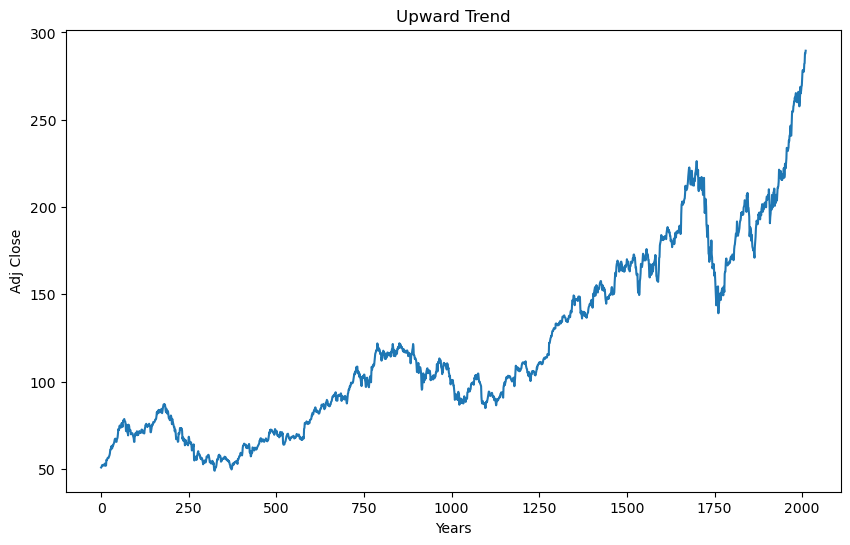

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(data['Adj Close'])
plt.xlabel('Years')
plt.ylabel('Adj Close')
plt.title('Upward Trend')
plt.show()

In [27]:
# Differencing y(t)=y(t)-y(t-1)
data[' Adj Close First Difference'] = data['Adj Close'] -data['Adj Close'].shift(1)

In [28]:
# After differencing ADF test
adf_test(data[' Adj Close First Difference'].dropna())

Agumented Dicky-Fuller test
ADF test statistic :     -1.347264e+01
p-value :                 3.359045e-25
No. of Lags :             8.000000e+00
critical value (1%) :    -3.433622e+00
critical value (5%) :    -2.862985e+00
critical value (10%) :   -2.567540e+00

Reject the null hypothesis
Data is stationary


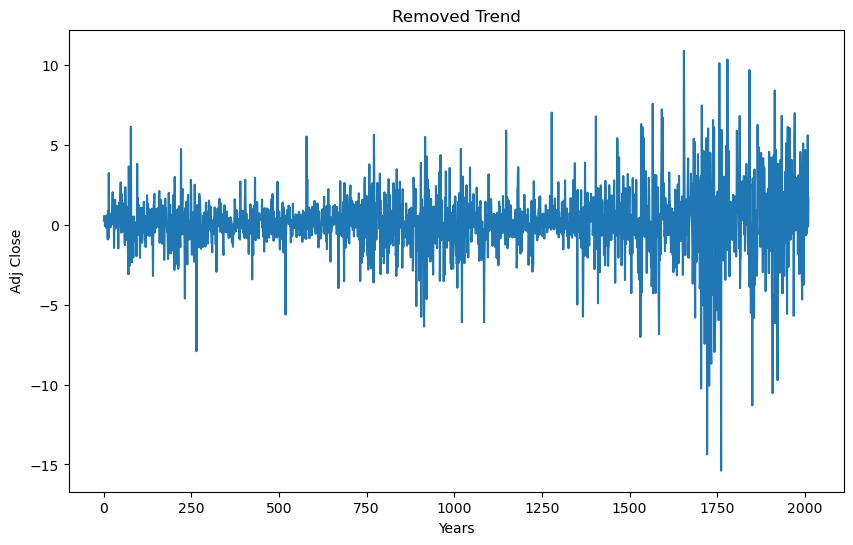

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(data[' Adj Close First Difference'])
plt.xlabel('Years')
plt.ylabel('Adj Close')
plt.title('Removed Trend')
plt.show()

In [30]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

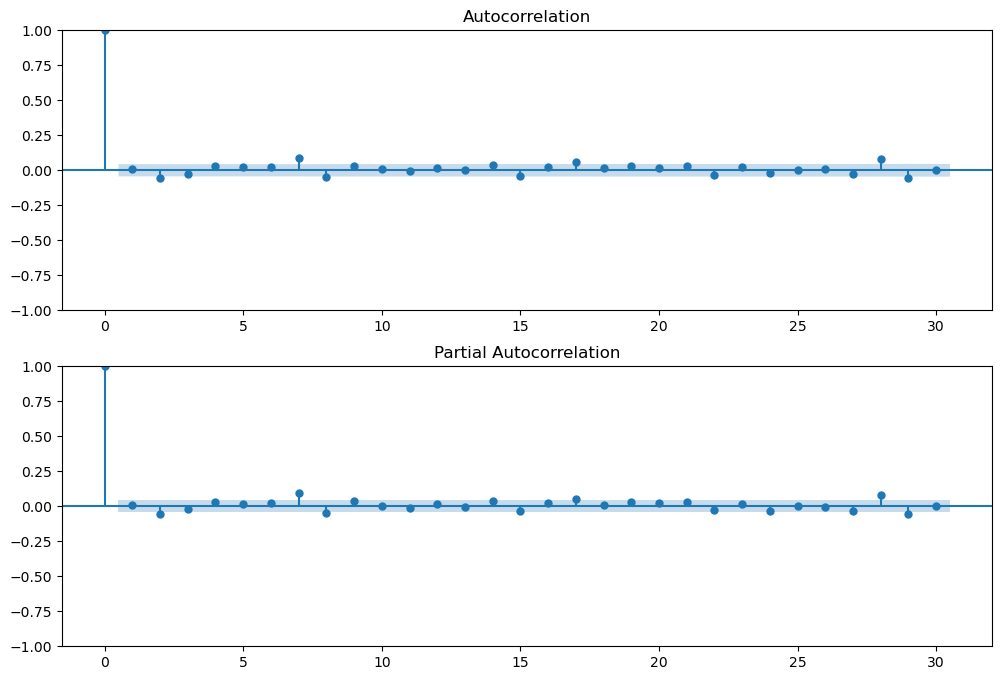

In [31]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = plot_acf(data[' Adj Close First Difference'].iloc[2:],lags=30,ax=ax1)
ax2 = fig.add_subplot(212)
fig = plot_pacf(data[' Adj Close First Difference'].iloc[2:],lags=30,ax=ax2)

# model building

In [32]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [33]:

# Convert the Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

In [34]:

# Extract additional features from the Date column
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day

In [35]:
# Select features and target
features = ['Open', 'High', 'Low', 'Volume', 'Year', 'Month', 'Day']
target = 'Close'

In [36]:

X = data[features]
y = data[target]

In [37]:

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
# Train a Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [40]:
# Make predictions using Linear Regression
y_pred_linear = linear_model.predict(X_test_scaled)

In [41]:

# Evaluate the Linear Regression model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

In [42]:
print("Linear Regression:")
print("Mean Squared Error:", mse_linear)
print("R-squared:", r2_linear)


Linear Regression:
Mean Squared Error: 0.7101166204635102
R-squared: 0.9997181651120701


In [43]:
# Train a Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [44]:
# Make predictions using Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)

In [45]:
# Evaluate the Random Forest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [46]:

print("\nRandom Forest Regression:")
print("Mean Squared Error:", mse_rf)
print("R-squared:", r2_rf)


Random Forest Regression:
Mean Squared Error: 1.0640782135963325
R-squared: 0.9995776829390618


In [47]:

# Display the first 10 predictions alongside actual values
predictions = pd.DataFrame({
    'Actual': y_test.values,
    'Linear_Predicted': y_pred_linear,
    'RF_Predicted': y_pred_rf
})
print("\nFirst 10 Predictions:")
print(predictions.head(20))


First 10 Predictions:
        Actual  Linear_Predicted  RF_Predicted
0   144.119995        143.925824    144.001099
1    73.215714         73.049167     72.776428
2    63.970001         63.940668     63.626943
3   155.570007        155.609573    156.193199
4    69.871429         69.945223     70.040985
5    75.881432         75.675573     75.697943
6    95.180000         95.059374     94.864329
7    66.382858         66.253178     66.286571
8    94.250000         94.096367     94.353843
9    76.559998         76.607839     77.127713
10  123.250000        123.335701    123.144898
11  213.259995        213.184691    215.388200
12   94.959999         95.374431     95.174100
13   76.694283         76.487267     77.003170
14  144.179993        144.448664    143.957200
15  107.339996        106.997610    107.661900
16  179.979996        179.201913    178.900899
17   83.428574         82.832920     83.379658
18  155.860001        156.220821    155.033600
19   75.250000         74.904203     

In [48]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

In [49]:
# Convert Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

In [50]:
# Set the Date column as the index
data.set_index('Date', inplace=True)

In [51]:

# Select the target variable for forecasting (e.g., 'Close')
series = data['Close']

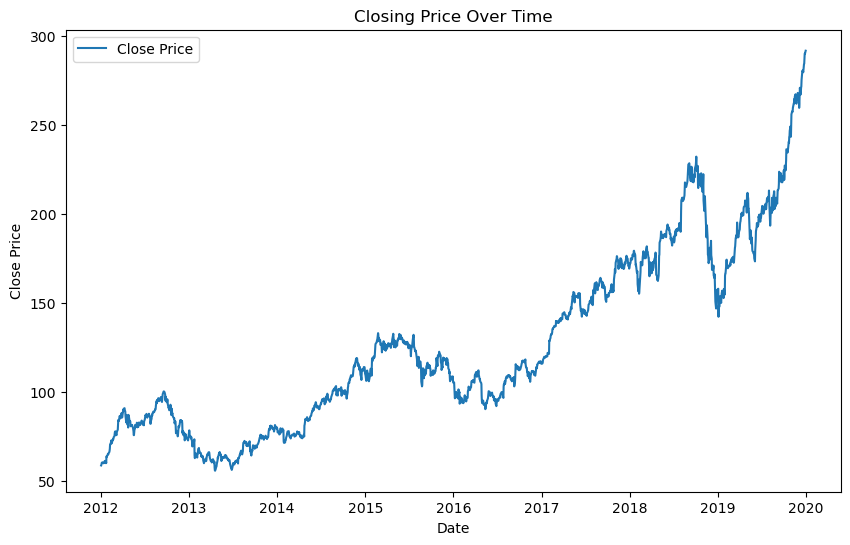

In [52]:
# Plot the time series
plt.figure(figsize=(10, 6))
plt.plot(series, label='Close Price')
plt.title('Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [53]:
# Check for stationarity using the Augmented Dickey-Fuller (ADF) test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:", result[4])
    if result[1] <= 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

print("\nADF Test Result for Close Prices:")
adf_test(series)


ADF Test Result for Close Prices:
ADF Statistic: 1.2193701254378044
p-value: 0.996117017803201
Critical Values: {'1%': -3.433622218212895, '5%': -2.8629854902259004, '10%': -2.5675395171404802}
The series is not stationary.


In [54]:
# Differencing to make the series stationary if needed
diff_series = series.diff().dropna()

In [55]:
print("\nADF Test Result After Differencing:")
adf_test(diff_series)



ADF Test Result After Differencing:
ADF Statistic: -13.625534323873255
p-value: 1.7631231987209532e-25
Critical Values: {'1%': -3.433622218212895, '5%': -2.8629854902259004, '10%': -2.5675395171404802}
The series is stationary.


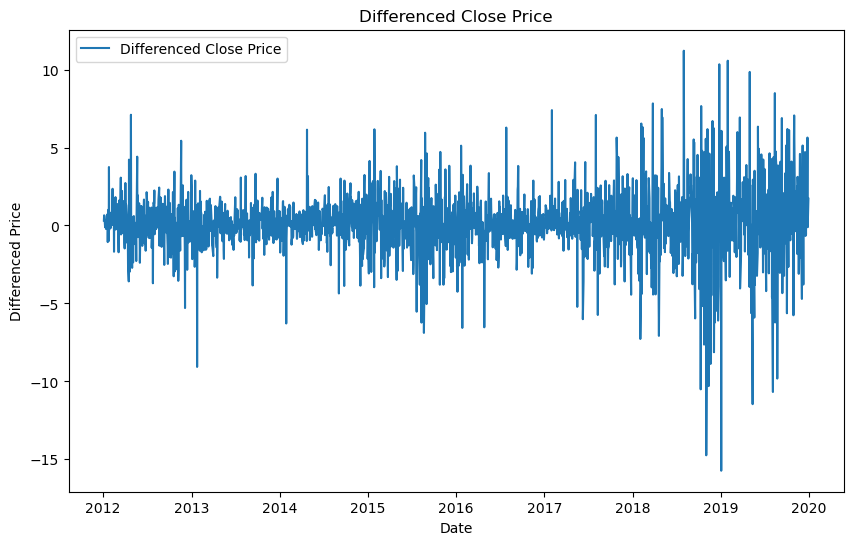

In [56]:
# Plot the differenced series
plt.figure(figsize=(10, 6))
plt.plot(diff_series, label='Differenced Close Price')
plt.title('Differenced Close Price')
plt.xlabel('Date')
plt.ylabel('Differenced Price')
plt.legend()
plt.show()

In [57]:
# Fit the ARIMA model
# Define p, d, q parameters
p = 5  # Autoregressive order
d = 1  # Differencing order
q = 2  # Moving average order

In [58]:
arima_model = ARIMA(series, order=(p, d, q))
arima_result = arima_model.fit()

In [59]:

# Print model summary
print("\nARIMA Model Summary:")
print(arima_result.summary())


ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2011
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -4361.977
Date:                Wed, 29 Jan 2025   AIC                           8739.954
Time:                        21:44:22   BIC                           8784.801
Sample:                             0   HQIC                          8756.417
                               - 2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0730      0.174      0.421      0.674      -0.267       0.413
ar.L2          0.7202      0.166      4.332      0.000       0.394       1.046
ar.L3         -0.0241      0.0

In [60]:
# Forecasting
forecast_steps = 30  # Number of steps to forecast
forecast = arima_result.forecast(steps=forecast_steps)

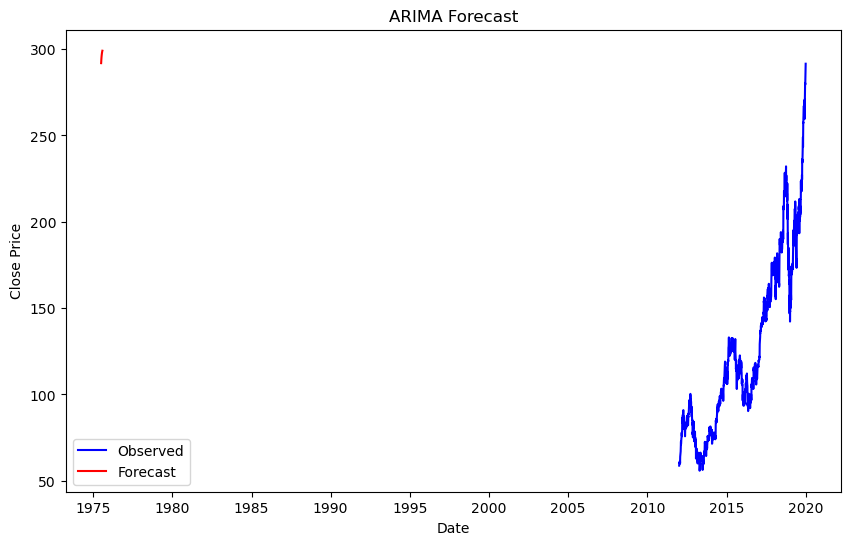

In [61]:
# Plot the original series and the forecast
plt.figure(figsize=(10, 6))
plt.plot(series, label='Observed', color='blue')
plt.plot(forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [62]:
# Evaluate the model
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]
arima_model_train = ARIMA(train, order=(p, d, q))
arima_result_train = arima_model_train.fit()

In [63]:
# Make predictions
pred = arima_result_train.forecast(steps=len(test))
mse = mean_squared_error(test, pred)
print("\nMean Squared Error (MSE):", mse)


Mean Squared Error (MSE): 1152.9990380218078


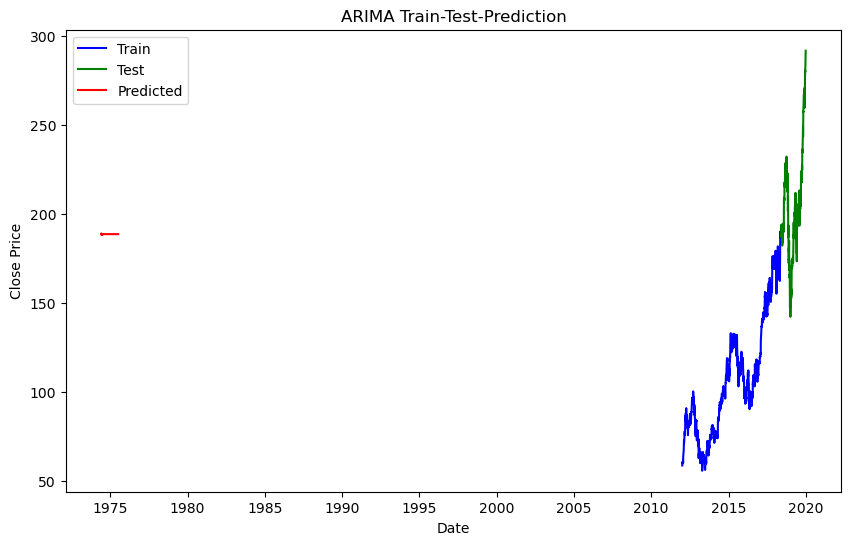

In [64]:
# Plot train, test, and predictions
plt.figure(figsize=(10, 6))
plt.plot(train, label='Train', color='blue')
plt.plot(test, label='Test', color='green')
plt.plot(pred, label='Predicted', color='red')
plt.title('ARIMA Train-Test-Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [69]:
import pandas as pd
import pickle
from statsmodels.tsa.arima.model import ARIMA

# Load dataset
file_path =  "C:\\Users\\91705\\data science\\DS19thJuly24-2-30-to-4-30-main_(1)[1]\\AAPL.csv"  # Replace with your actual file path
data = pd.read_csv(file_path)

# Convert Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Select the target variable (e.g., 'Close' price)
series = data['Close']

# Train ARIMA model (Adjust p, d, q as needed)
p, d, q = 5, 1, 2
arima_model = ARIMA(series, order=(p, d, q))
fitted_model = arima_model.fit()

# Save the trained model using Picklepickle_filename = 'arima_model.pkl'
pickle
with open('arima_model.pkl', 'wb') as f:
    pickle.dump(fitted_model, f)

print("ARIMA model saved as 'arima_model.pkl'")

ARIMA model saved as 'arima_model.pkl'


In [68]:
# Load the saved ARIMA model
with open('arima_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Make future predictions
steps = 30  # Number of days to forecast
forecast = loaded_model.forecast(steps=steps)

# Display forecasted values
print("Forecasted Values:", forecast)

Forecasted Values: 2011    291.855970
2012    292.169539
2013    292.711170
2014    293.059889
2015    293.585919
2016    293.899561
2017    294.341715
2018    294.638178
2019    295.020653
2020    295.299518
2021    295.631358
2022    295.889488
2023    296.179392
2024    296.416314
2025    296.671077
2026    296.887079
2027    297.111943
2028    297.307924
2029    297.507079
2030    297.684276
2031    297.861124
2032    298.020925
2033    298.178278
2034    298.322118
2035    298.462337
2036    298.591630
2037    298.716722
2038    298.832818
2039    298.944512
2040    299.048677
Name: predicted_mean, dtype: float64
